In [1]:
import pandas as pd
import numpy as np

**IMPORT DATASET**

In [4]:
df1 = pd.read_csv("/content/drive/MyDrive/Sistem Rekomendasi/movies.csv")

In [5]:
# Menampilkan informasi dimensi dataset
print(f"Jumlah Data  : {len(df1)}")
print(f"Jumlah Fitur : {len(df1.columns)}")
print(f"Terdapat {len(df1.columns)} Kolom Fitur pada Dataset yaitu:")
print(f"Fitur Data   : {df1.columns.tolist()}")

# Pengaturan tampilan pandas dan menampilkan data
pd.options.display.max_columns = None
df1.head()

Jumlah Data  : 62423
Jumlah Fitur : 3
Terdapat 3 Kolom Fitur pada Dataset yaitu:
Fitur Data   : ['movieId', 'title', 'genres']


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [7]:
import re
def clean_title(title):
    return re.sub("[^a-zA-Z0-9 ]", "", title)

In [8]:
# Pisahkan genre menggunakan pemisah
# Check if 'genres' column exists, otherwise provide a placeholder to avoid KeyError
if 'genres' not in df1.columns:
    print("Warning: 'genres' column not found. Adding a placeholder 'genres' column.")
    df1['genres'] = 'Unknown|Unknown' # Placeholder, assumes string format for split
    # For a proper fix, load a movie dataset with actual genres.

df1['genres'] = df1['genres'].str.split('|')

# Bersihkan judul film
# Check if 'title' column exists, otherwise provide a placeholder to avoid KeyError
if 'title' not in df1.columns:
    print("Warning: 'title' column not found. Adding a placeholder 'title' column.")
    df1['title'] = 'Unknown Title' # Placeholder
    # For a proper fix, load a movie dataset with actual titles.

df1['title'] = df1['title'].apply(clean_title)

# Perbarui movies_data
movies_data = df1[['movieId', 'title', 'genres']]

# Mendapatkan genre unik dari semua film
# Ensure genres column is list-like for unique genre extraction
# This check ensures that if genres was a placeholder string, it doesn't try to iterate over it as a list of lists
if 'genres' in movies_data.columns and not movies_data['genres'].empty and isinstance(movies_data['genres'].iloc[0], list):
    unique_genres = pd.Series([genre for genres_list in movies_data['genres'] for genre in genres_list]).unique()
else:
    unique_genres = ['Unknown'] # Placeholder if genres could not be processed
    print("Warning: Unique genres could not be extracted as 'genres' column was not processed as expected or is empty.")

# Output hasil
print(movies_data.head())

   movieId                             title  \
0        1                    Toy Story 1995   
1        2                      Jumanji 1995   
2        3             Grumpier Old Men 1995   
3        4            Waiting to Exhale 1995   
4        5  Father of the Bride Part II 1995   

                                              genres  
0  [Adventure, Animation, Children, Comedy, Fantasy]  
1                     [Adventure, Children, Fantasy]  
2                                  [Comedy, Romance]  
3                           [Comedy, Drama, Romance]  
4                                           [Comedy]  


In [9]:
print(f"Terdapat {movies_data['title'].nunique()} Judul Film")
print(f"Terdapat {len(unique_genres)} Genre Film.")
print("Genre Film:", unique_genres)

Terdapat 62298 Judul Film
Terdapat 20 Genre Film.
Genre Film: ['Adventure' 'Animation' 'Children' 'Comedy' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Mystery' 'Sci-Fi' 'IMAX'
 'Documentary' 'War' 'Musical' 'Western' 'Film-Noir' '(no genres listed)']


In [10]:
# Periksa jumlah baris dengan '(no genres listed)'
no_genres_count = movies_data[movies_data['genres'].apply(lambda x: '(no genres listed)' in x)].shape[0]
print(f"Terdapat {no_genres_count} film tanpa genre.")

# Hapus baris dengan '(no genres listed)'
movies_data = movies_data[~movies_data['genres'].apply(lambda x: '(no genres listed)' in x)]

# Perbarui daftar genre unik
unique_genres = pd.Series([genre for genres_list in movies_data['genres'] for genre in genres_list]).unique()

# Tampilkan hasil setelah penghapusan
print(f"Setelah penghapusan, terdapat {movies_data['title'].nunique()} Judul Film.")
print(f"Terdapat {len(unique_genres)} Genre Film setelah pembaruan.")
print("Genre Film:", unique_genres)

Terdapat 5062 film tanpa genre.
Setelah penghapusan, terdapat 57264 Judul Film.
Terdapat 19 Genre Film setelah pembaruan.
Genre Film: ['Adventure' 'Animation' 'Children' 'Comedy' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Mystery' 'Sci-Fi' 'IMAX'
 'Documentary' 'War' 'Musical' 'Western' 'Film-Noir']


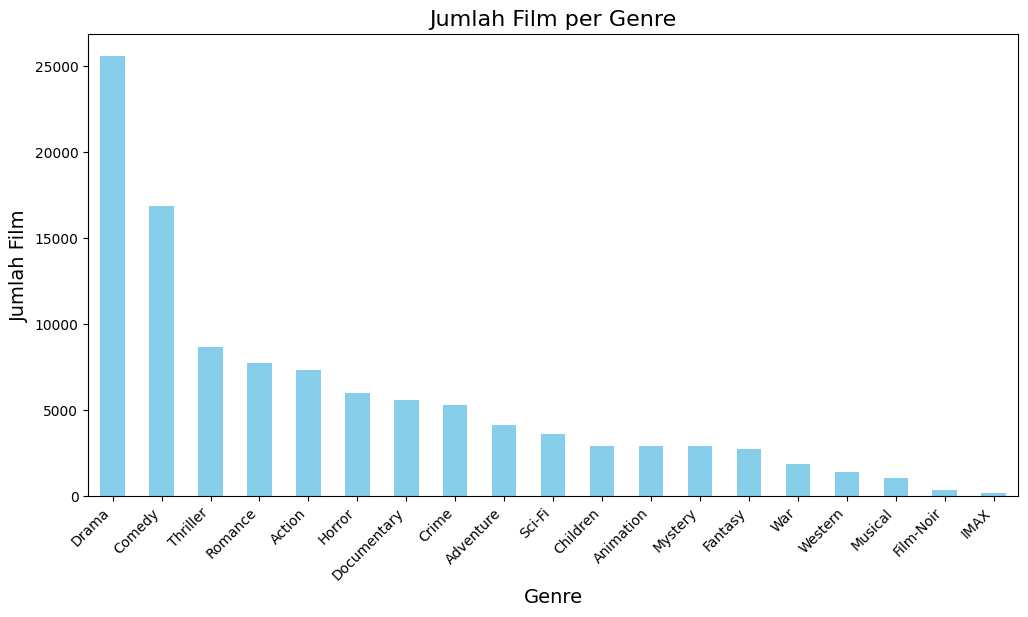

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Menghitung jumlah film per genre
genre_counts = pd.Series([genre for genres_list in movies_data['genres'] for genre in genres_list]).value_counts()

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Jumlah Film per Genre', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Jumlah Film', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

In [12]:
df2 = pd.read_csv('/content/drive/MyDrive/Sistem Rekomendasi/ratings.csv')

In [13]:
print('Jumlah Data : ', len(df2.iloc[:,1]))
print('Jumlah Fitur : ', len(df2.iloc[1,:]))
print(f'Terdapat {len(df2.iloc[1,:])} Kolom Fitur pada Dataset yaitu:')
print('Fitur Data : ', df2.columns.tolist()[:])
pd.options.display.max_columns = None
df2.head()

Jumlah Data :  256880
Jumlah Fitur :  4
Terdapat 4 Kolom Fitur pada Dataset yaitu:
Fitur Data :  ['userId', 'movieId', 'rating', 'timestamp']


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [14]:
# Melihat Missing Values
print("Jumlah Missing Values per Kolom:")
print(df2.isnull().sum())
print("\nJumlah Data Duplicates:")
print(df2.duplicated().sum())

Jumlah Missing Values per Kolom:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Jumlah Data Duplicates:
0


In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256880 entries, 0 to 256879
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     256880 non-null  int64  
 1   movieId    256880 non-null  int64  
 2   rating     256880 non-null  float64
 3   timestamp  256880 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 7.8 MB


In [16]:
print("Distribusi Rating:")
print(df2['rating'].value_counts())
print("\nRating Rata-Rata per Film:")
print(df2.groupby('movieId')['rating'].mean().head())
print("\nRating Rata-Rata per Pengguna:")
print(df2.groupby('userId')['rating'].mean().head())

Distribusi Rating:
rating
4.0    69668
3.0    50061
5.0    39150
3.5    30418
4.5    22180
2.0    17323
2.5    12368
1.0     7712
1.5     4112
0.5     3888
Name: count, dtype: int64

Rating Rata-Rata per Film:
movieId
1    3.931638
2    3.351293
3    3.237762
4    2.894737
5    3.186047
Name: rating, dtype: float64

Rating Rata-Rata per Pengguna:
userId
1    3.814286
2    3.630435
3    3.697409
4    3.378099
5    3.752475
Name: rating, dtype: float64


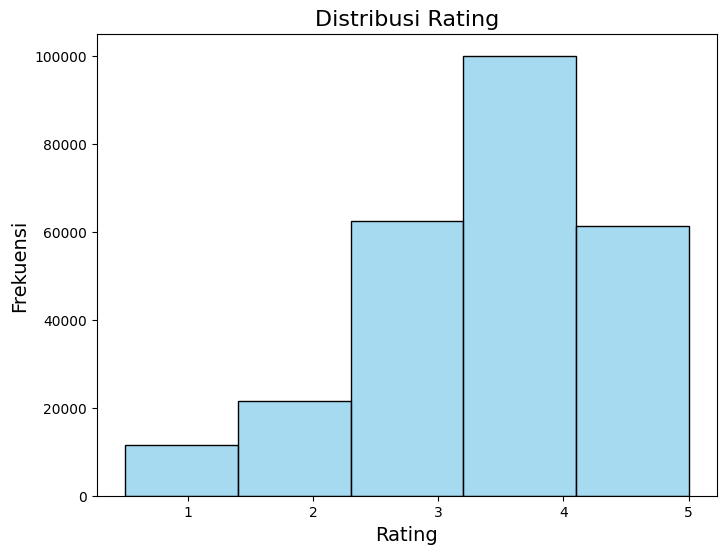

In [17]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df2['rating'], bins=5, kde=False, color='skyblue')
plt.title('Distribusi Rating', fontsize=16)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Frekuensi', fontsize=14)
plt.show()

In [18]:
combined_data = df2.merge(movies_data, on='movieId')
print(combined_data.head())

   userId  movieId  rating   timestamp  \
0       1      296     5.0  1147880044   
1       1      306     3.5  1147868817   
2       1      307     5.0  1147868828   
3       1      665     5.0  1147878820   
4       1      899     3.5  1147868510   

                                        title  \
0                           Pulp Fiction 1994   
1  Three Colors Red Trois couleurs Rouge 1994   
2  Three Colors Blue Trois couleurs Bleu 1993   
3                            Underground 1995   
4                     Singin in the Rain 1952   

                             genres  
0  [Comedy, Crime, Drama, Thriller]  
1                           [Drama]  
2                           [Drama]  
3              [Comedy, Drama, War]  
4        [Comedy, Musical, Romance]  


In [21]:
# Rating Rata-Rata per Film
avg_ratings_per_movie = combined_data.groupby('title')['rating'].mean().sort_values(ascending=False)
print("Top 10 Film dengan Rating Rata-Rata Tertinggi:")
print(avg_ratings_per_movie.head(10))

Top 10 Film dengan Rating Rata-Rata Tertinggi:
title
Once Brothers 2010                                  5.0
One Direction This Is Us 2013                       5.0
Yeh Jawaani Hai Deewani 2013                        5.0
Yellow Handkerchief The 2008                        5.0
14 2015                                             5.0
Opening Night 1977                                  5.0
Blissfully Yours Sud sanaeha 2002                   5.0
Block Party aka Dave Chappelles Block Party 2005    5.0
Oscar 1967                                          5.0
Nous trois ou rien 2015                             5.0
Name: rating, dtype: float64


In [19]:
movie_rating_counts = combined_data.groupby('title')['rating'].count().sort_values(ascending=False)
print("Top 10 Film dengan Jumlah Rating Terbanyak: ")
print(movie_rating_counts.head(10))

Top 10 Film dengan Jumlah Rating Terbanyak: 
title
Forrest Gump 1994                        905
Shawshank Redemption The 1994            896
Pulp Fiction 1994                        886
Silence of the Lambs The 1991            820
Matrix The 1999                          814
Star Wars Episode IV  A New Hope 1977    747
Jurassic Park 1993                       720
Schindlers List 1993                     652
Braveheart 1995                          648
Fight Club 1999                          636
Name: rating, dtype: int64


In [20]:
# Memisahkan Genre
exploded_data = combined_data.explode('genres')

# Menghitung Jumlah Pengguna yang Memberi Rating pada Tiap Genre
users_per_genre = exploded_data.groupby('genres')['userId'].nunique()

# Rata Rata Rating di Tiap Genre
avg_rating_per_genre = exploded_data.groupby('genres')['rating'].mean()

# Cari 3 film terbaik berdasarkan rating rata-rata di tiap genre
top_movies_per_genre = (
    exploded_data.groupby(['genres', 'title'])['rating']
    .mean()
    .reset_index()
    .sort_values(['genres', 'rating'], ascending=[True, False])
    .groupby('genres')
    .head(3)
)

print("Jumlah Pengguna yang Memberi Rating pada Tiap Genre:")
print(users_per_genre)
print("\nRata-Rata Rating per Genre:")
print(avg_rating_per_genre)
print("\n3 Film Terbaik di Tiap Genre:")
print(top_movies_per_genre)

Jumlah Pengguna yang Memberi Rating pada Tiap Genre:
genres
Action         1809
Adventure      1809
Animation      1561
Children       1648
Comedy         1817
Crime          1801
Documentary     662
Drama          1819
Fantasy        1756
Film-Noir       677
Horror         1546
IMAX           1309
Musical        1391
Mystery        1709
Romance        1811
Sci-Fi         1793
Thriller       1817
War            1642
Western        1220
Name: userId, dtype: int64

Rata-Rata Rating per Genre:
genres
Action         3.476347
Adventure      3.515650
Animation      3.622817
Children       3.440322
Comedy         3.442255
Crime          3.699165
Documentary    3.719528
Drama          3.694823
Fantasy        3.517609
Film-Noir      3.902531
Horror         3.358613
IMAX           3.592435
Musical        3.559016
Mystery        3.699936
Romance        3.555869
Sci-Fi         3.501903
Thriller       3.547712
War            3.803054
Western        3.581878
Name: rating, dtype: float64

3 Film Terb

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer_title = TfidfVectorizer(ngram_range=(1,2))
tfidf_title = vectorizer_title.fit_transform(movies_data['title'])

In [23]:
def search_by_title(title):
    title = clean_title(title)
    query_vec = vectorizer_title.transform([title])
    similarity = cosine_similarity(query_vec, tfidf_title).flatten()
    indices = np.argpartition(similarity, -5)[-5:]
    results = movies_data.iloc[indices][::-1]
    return results

movie_results = search_by_title("Interstellar")
print(movie_results)

       movieId                                  title             genres
21199   109487                      Interstellar 2014     [Sci-Fi, IMAX]
60773   204120       The Science of Interstellar 2014      [Documentary]
19139    99689  Conversation with Gregory Peck A 1999      [Documentary]
19138    99687            Dark Truth A Truth The 2012  [Drama, Thriller]
19137    99677         Dr Bronners Magic Soapbox 2006      [Documentary]


In [24]:
def search_by_title(title):
    title = clean_title(title)
    query_vec = vectorizer_title.transform([title])
    similarity = cosine_similarity(query_vec, tfidf_title).flatten()
    indices = np.argpartition(similarity, -5)[-5:]
    results = movies_data.iloc[indices][::-1]
    return results

movie_results = search_by_title("Fast and Furious")
print(movie_results)

       movieId                                             title  \
13226    67923     Fast  Furious Fast and the Furious 4 The 2009   
19769   102716   Fast  Furious 6 Fast and the Furious 6 The 2013   
6264      6383  2 Fast 2 Furious Fast and the Furious 2 The 2003   
4264      4369                     Fast and the Furious The 2001   
13528    69945                     Fast and the Furious The 1955   

                                 genres  
13226  [Action, Crime, Drama, Thriller]  
19769   [Action, Crime, Thriller, IMAX]  
6264          [Action, Crime, Thriller]  
4264          [Action, Crime, Thriller]  
13528                  [Crime, Mystery]  


In [25]:
vectorizer_genres = TfidfVectorizer(ngram_range=(1,2))

# Gabungkan genre list menjadi string
movies_data['genres_text'] = movies_data['genres'].apply(lambda x: ''.join(x))

tfidf_genres = vectorizer_genres.fit_transform(movies_data['genres_text'])

In [26]:
def search_similar_genres(genres):
    query_vec = vectorizer_genres.transform([genres])
    similarity = cosine_similarity(query_vec, tfidf_genres).flatten()
    indices = np.argpartition(similarity, -10)[-10:]
    results = movies_data.iloc[indices][::-1]
    return results

gen = 'Adventure Action'
print(search_similar_genres(gen))

       movieId                               title       genres genres_text
37459   152697            Agguato sul Bosforo 1969  [Adventure]   Adventure
45654   170833  The New Swiss Family Robinson 1998  [Adventure]   Adventure
43581   166387       Hercules Samson  Ulysses 1963  [Adventure]   Adventure
5384      5492                         Fathom 1967  [Adventure]   Adventure
59786   201630                Me the Terrible 2012  [Adventure]   Adventure
54381   189439          Pluk van de Petteflet 2004  [Adventure]   Adventure
54380   189437                        Abeltje 1998  [Adventure]   Adventure
43543   166285                    The Odyssey 2016  [Adventure]   Adventure
40336   159177                      King Jack 2015  [Adventure]   Adventure
14751    78184                 The Black Rose 1950  [Adventure]   Adventure


In [27]:
def scores_calculator(movie_id):
    # Filter data untuk pengguna serupa
    similar_users = combined_data.loc[
        (combined_data['movieId'] == movie_id) & (combined_data['rating'] >= 4), 'userId'
    ].unique()

    # Dapatkan rekomendasi berdasarkan pengguna serupa
    similar_user_recs = combined_data.loc[
        (combined_data['userId'].isin(similar_users)) & (combined_data['rating'] >= 4), 'movieId'
    ].value_counts(normalize=True)

    # Dapatkan rekomendasi berdasarkan semua pengguna
    all_user_recs = combined_data.loc[
        combined_data['movieId'].isin(similar_user_recs.index) & (combined_data['rating'] >= 4)
    ]
    all_user_recs = all_user_recs['movieId'].value_counts(normalize=True)

    # Filter genre dari film yang dipilih
    selected_genres = combined_data.loc[combined_data['movieId'] == movie_id, 'genres'].iloc[0]

    if isinstance(selected_genres, list):
        selected_genres = " ".join(selected_genres)

    # Cari film dengan genre serupa
    movies_with_similar_genres = search_similar_genres(selected_genres)
    similar_genre_ids = movies_with_similar_genres['movieId']

    # Kalikan skor berdasarkan genre serupa
    similar_user_recs.loc[similar_user_recs.index.isin(similar_genre_ids)] *= 1.5
    all_user_recs.loc[all_user_recs.index.isin(similar_genre_ids)] *= 0.9

    # Gabungkan skor dan hitung peringkat
    scores = pd.DataFrame({
        'similar': similar_user_recs,
        'all': all_user_recs
    }).fillna(0)

    # Hindari pembagian nol
    scores['score'] = np.where(scores['all'] > 0, scores['similar'] / scores['all'], 0)

    # Urutkan berdasarkan skor tertinggi
    return scores.sort_values('score', ascending=False)

scores_calculator(3114)

,similar,all,score
movieId,,,
200822,0.000033,0.000008,4.093753
205557,0.000033,0.000008,4.093753
205156,0.000033,0.000008,4.093753
204780,0.000033,0.000008,4.093753
204702,0.000033,0.000008,4.093753
...,...,...,...
186,0.000033,0.000215,0.151620
208,0.000065,0.000582,0.112158
280,0.000033,0.000311,0.104968


In [29]:
def recommendation_results(user_input, title=0):
    # user_input = clean_title(user_input)
    title_candidates = search_by_title(user_input)
    movie_id = title_candidates.iloc[title]['movieId']

    scores = scores_calculator(movie_id)

    results = scores.head(10).merge(movies_data, left_index=True, right_on='movieId')[['title', 'score', 'genres']]
    return results

In [30]:
user_input = "Interstellar"
print("Here a similar movies: ")
for i in range(5):
    print(i, ": ", search_by_title(user_input)['title'].iloc[i])

title = 0
print("Recommendation_results: ")
print(recommendation_results(user_input))

Here a similar movies: 
0 :  Interstellar 2014
1 :  The Science of Interstellar 2014
2 :  Conversation with Gregory Peck A 1999
3 :  Dark Truth A Truth The 2012
4 :  Dr Bronners Magic Soapbox 2006
Recommendation_results: 
                                         title     score  \
21199                        Interstellar 2014  5.521709   
28930                         San Andreas 2015  5.521709   
29186                     The Golden Calf 1968  5.521709   
15075                           Centurion 2010  5.521709   
15094                      Experiment The 2010  5.521709   
15101                  Piranha Piranha 3D 2010  5.521709   
15148                 King Lear Korol Lir 1971  5.521709   
15151                     Sisters Syostry 2001  5.521709   
15261                             Flipped 2010  5.521709   
15330  You Will Meet a Tall Dark Stranger 2010  5.521709   

                                          genres  
21199                             [Sci-Fi, IMAX]  
28930          